In [8]:
point = "P0002"

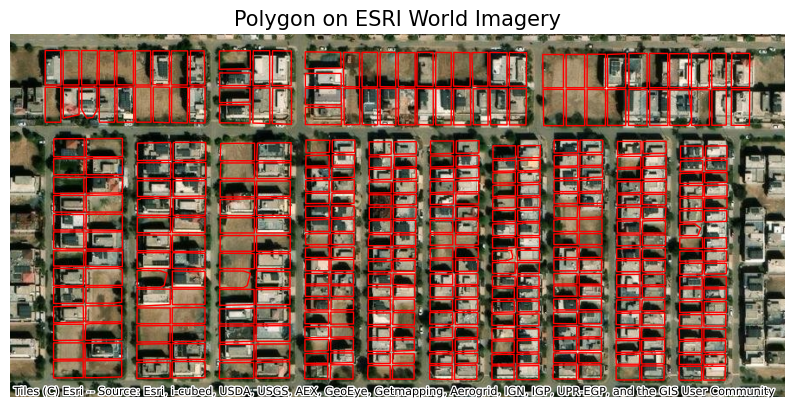

In [9]:
import pandas as pd
import geopandas as gpd
from shapely import wkt
import matplotlib.pyplot as plt
import contextily as cx

# 1. Load the Excel file
file_path = "pipeline_output/final_dataset.xlsx"  # Change to your filename
df = pd.read_excel(file_path, sheet_name="plots_stage2")

df = df[df["point_id"] == point]
# 2. Convert WKT string to a Shapely object
# Assuming the WKT is in a column named 'geometry'
df['polygon_wkt'] = df['polygon_wkt'].apply(wkt.loads)

# 3. Create a GeoDataFrame
# We set the CRS to EPSG:4326 (Lat/Lon) because that's what the WKT looks like
gdf = gpd.GeoDataFrame(df, geometry='polygon_wkt', crs="EPSG:4326")

# 4. Reproject to Web Mercator (EPSG:3857) 
# Most map tile providers (like ESRI) require this projection for plotting
gdf_3857 = gdf.to_crs(epsg=3857)

# 5. Plotting
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the polygon
# 'edgecolor' makes the boundary visible, 'facecolor' can be 'none' or a transparent color
gdf_3857.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=1)

# 6. Add ESRI Satellite Imagery
cx.add_basemap(ax, source=cx.providers.Esri.WorldImagery)

# Remove axis for a cleaner "image" look
ax.set_axis_off()

plt.title("Polygon on ESRI World Imagery", fontsize=15)
plt.show()

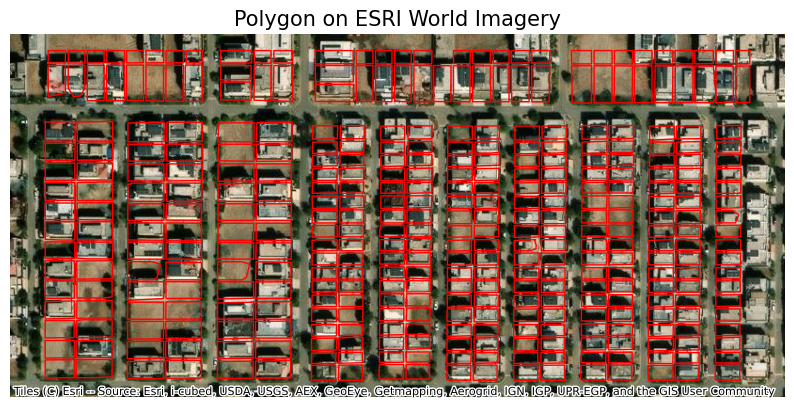

In [10]:
import pandas as pd
import geopandas as gpd
from shapely import wkt
import matplotlib.pyplot as plt
import contextily as cx

# 1. Load the Excel file
file_path = "pipeline_output/final_dataset.xlsx"  # Change to your filename
df = pd.read_excel(file_path, sheet_name="plots_stage1")

df = df[df["point_id"] == point]
# 2. Convert WKT string to a Shapely object
# Assuming the WKT is in a column named 'geometry'
df['polygon_wkt'] = df['polygon_wkt'].apply(wkt.loads)

# 3. Create a GeoDataFrame
# We set the CRS to EPSG:4326 (Lat/Lon) because that's what the WKT looks like
gdf = gpd.GeoDataFrame(df, geometry='polygon_wkt', crs="EPSG:4326")

# 4. Reproject to Web Mercator (EPSG:3857) 
# Most map tile providers (like ESRI) require this projection for plotting
gdf_3857 = gdf.to_crs(epsg=3857)

# 5. Plotting
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the polygon
# 'edgecolor' makes the boundary visible, 'facecolor' can be 'none' or a transparent color
gdf_3857.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=1)

# 6. Add ESRI Satellite Imagery
cx.add_basemap(ax, source=cx.providers.Esri.WorldImagery)

# Remove axis for a cleaner "image" look
ax.set_axis_off()

plt.title("Polygon on ESRI World Imagery", fontsize=15)
plt.show()

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx
from shapely.geometry import Point

def visualize_roads_at_coord(shapefile_path, lon, lat, buffer_meters=1000):
    # 1. Load the OSM Roads shapefile
    print("Loading roads shapefile (this may take a moment)...")
    roads = gpd.read_file(shapefile_path)
    
    # 2. Setup Coordinate Reference Systems
    if roads.crs is None:
        roads.set_crs(epsg=4326, inplace=True)
    
    # Target point in Web Mercator for buffering
    target_gdf = gpd.GeoDataFrame(index=[0], crs="EPSG:4326", geometry=[Point(lon, lat)])
    target_3857 = target_gdf.to_crs(epsg=3857)
    point_geom = target_3857.geometry.iloc[0]
    
    # 3. Spatial Filter (Crop to the area of interest)
    # Buffering by 1km to see the network structure
    view_area = point_geom.buffer(buffer_meters)
    roads_3857 = roads.to_crs(epsg=3857)
    local_roads = roads_3857[roads_3857.intersects(view_area)]

    if local_roads.empty:
        print(f"No roads found within {buffer_meters}m.")
        return

    # 4. Plotting
    fig, ax = plt.subplots(figsize=(12, 12))
    
    # Style mapping: thicker lines for main roads
    # 'fclass' is the standard OSM column for road type
    local_roads.plot(
        ax=ax, 
        column='fclass', 
        cmap='plasma', 
        linewidth=1.5, 
        legend=True,
        legend_kwds={'loc': 'upper right', 'title': 'Road Type'},
        zorder=2
    )
    
    # Add a marker for your specific coordinate
    ax.scatter(point_geom.x, point_geom.y, color='red', edgecolor='white', s=150, label='Center', zorder=3)

    # 5. Add ESRI Satellite Imagery
    cx.add_basemap(ax, source=cx.providers.Esri.WorldImagery, zorder=1)
    
    # Tighten the view
    ax.set_xlim(point_geom.x - buffer_meters, point_geom.x + buffer_meters)
    ax.set_ylim(point_geom.y - buffer_meters, point_geom.y + buffer_meters)
    
    ax.set_axis_off()
    plt.title(f"OSM Road Network: {lat}, {lon}", fontsize=15)
    plt.show()

# --- CHANGE THESE PATHS ---
ROADS_SHP = "OSM_data/gis_osm_roads_free_1.shp"

# Example: Near the Walled City of Lahore
visualize_roads_at_coord(ROADS_SHP, lon=74.32076887477058, lat=31.49093038390818)


Loading roads shapefile (this may take a moment)...


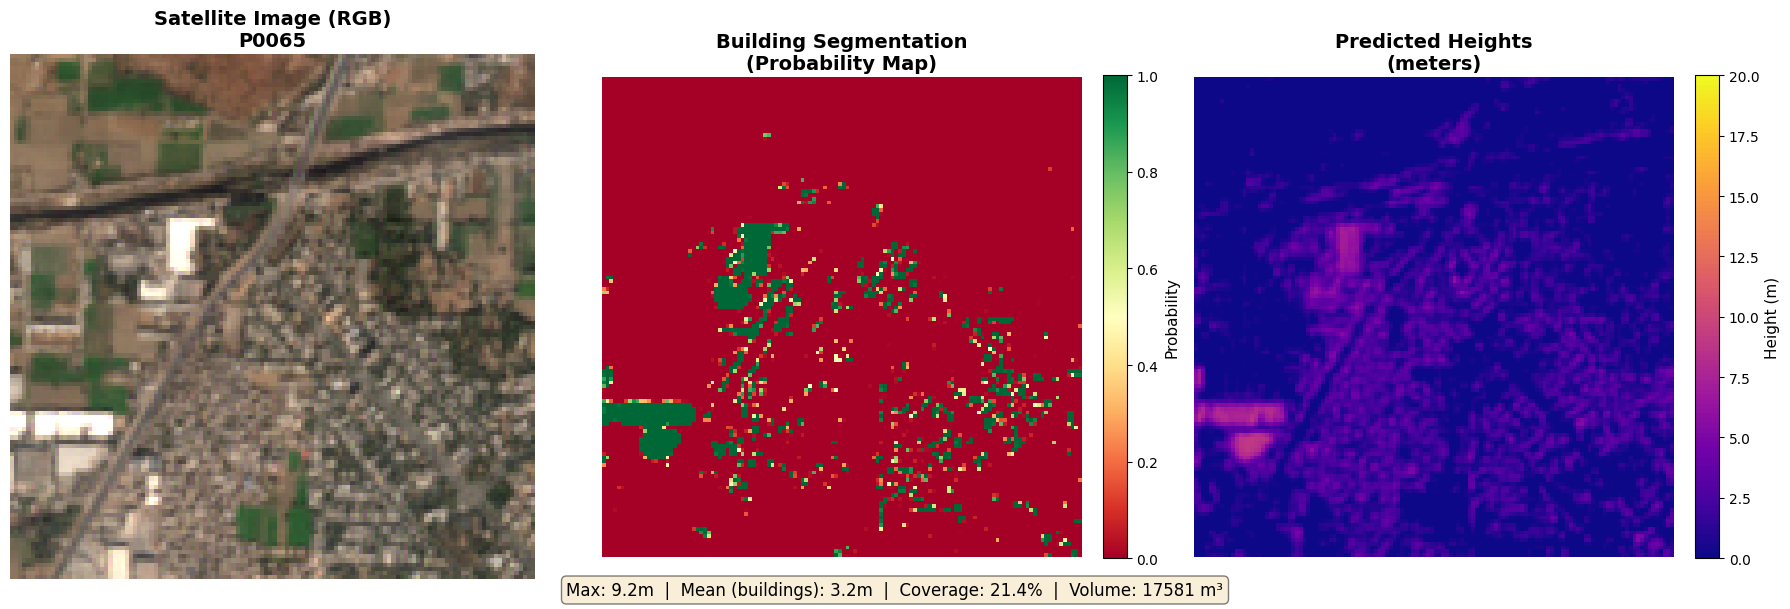


ANALYSIS: P0065
Max height:        9.20m
Mean height (all): 1.07m
Mean (buildings):  3.18m
Building pixels:   3509 / 16384
Coverage:          21.4%
Total volume:      17581 m³
Segmentation mean: 0.076


In [14]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# ============================================================================
# CONFIGURATION - Change these values for different samples
# ============================================================================
sample_id = "P0065"  # Change to your sample ID
pred_dir = "predictions"
data_root = "pipeline_output"  # Change for your data
timestep = 11  # Which month to show (0-11, 6=middle of year)

# ============================================================================
# LOAD DATA
# ============================================================================

# File paths
pred_path = f"pipeline_output\\P0090_Test\\height\\2024\\pred\\img_P0090_pred.tif"
seg_path = f"pipeline_output\\P0090_Test\\height\\2024\\pred\\img_P0090_seg.tif"
s2_path = f"pipeline_output\\P0090_Test\\height\\2024\\sat\\S2\\img_P0090_{timestep:02d}.tif"

# Load prediction (heights)
with rasterio.open(pred_path) as src:
    heights = src.read(1)

# Load segmentation
with rasterio.open(seg_path) as src:
    segmentation = src.read(1)

# Load satellite RGB (Sentinel-2: B04=Red, B03=Green, B02=Blue)
try:
    with rasterio.open(s2_path) as src:
        red = src.read(3)    # B04
        green = src.read(2)  # B03
        blue = src.read(1)   # B02
    
    # Stack and normalize
    rgb = np.stack([red, green, blue], axis=-1)
    rgb = np.clip(rgb, 0, 3000) / 3000.0
    rgb = np.power(rgb, 0.8)  # Gamma correction for better visibility
    has_satellite = True
except:
    has_satellite = False
    print("⚠ Satellite image not found")

# ============================================================================
# VISUALIZE
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Satellite RGB
if has_satellite:
    axes[0].imshow(rgb)
    axes[0].set_title(f'Satellite Image (RGB)\n{sample_id}', 
                     fontsize=14, fontweight='bold')
else:
    axes[0].text(0.5, 0.5, 'Satellite image\nnot available', 
                ha='center', va='center', fontsize=14)
    axes[0].set_title(f'Satellite Image\n{sample_id}', 
                     fontsize=14, fontweight='bold')
axes[0].axis('off')

# 2. Building Segmentation
im2 = axes[1].imshow(segmentation, cmap='RdYlGn', vmin=0, vmax=1)
axes[1].set_title('Building Segmentation\n(Probability Map)', 
                 fontsize=14, fontweight='bold')
axes[1].axis('off')
cbar2 = plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
cbar2.set_label('Probability', fontsize=11)

# 3. Height Prediction with custom colormap
colors = ['#0d0887', '#46039f', '#7201a8', '#9c179e', '#bd3786',
          '#d8576b', '#ed7953', '#fb9f3a', '#fdca26', '#f0f921']
cmap_height = LinearSegmentedColormap.from_list('height', colors, N=100)

im3 = axes[2].imshow(heights, cmap=cmap_height, vmin=0, vmax=20)
axes[2].set_title('Predicted Heights\n(meters)', 
                 fontsize=14, fontweight='bold')
axes[2].axis('off')
cbar3 = plt.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)
cbar3.set_label('Height (m)', fontsize=11)

# Add statistics
building_mask = heights > 2
mean_height = heights[building_mask].mean() if building_mask.sum() > 0 else 0
coverage = building_mask.sum() / building_mask.size * 100

stats_text = (f"Max: {heights.max():.1f}m  |  "
              f"Mean (buildings): {mean_height:.1f}m  |  "
              f"Coverage: {coverage:.1f}%  |  "
              f"Volume: {heights.sum():.0f} m³")

fig.text(0.5, 0.02, stats_text, ha='center', fontsize=12, 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(f'viz_{sample_id}.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# PRINT STATISTICS
# ============================================================================

print("\n" + "="*60)
print(f"ANALYSIS: {sample_id}")
print("="*60)
print(f"Max height:        {heights.max():.2f}m")
print(f"Mean height (all): {heights.mean():.2f}m")
print(f"Mean (buildings):  {mean_height:.2f}m")
print(f"Building pixels:   {building_mask.sum()} / {building_mask.size}")
print(f"Coverage:          {coverage:.1f}%")
print(f"Total volume:      {heights.sum():.0f} m³")
print(f"Segmentation mean: {segmentation.mean():.3f}")
print("="*60)

In [5]:
from sentinelhub import SHConfig

config = SHConfig()

config.sh_client_id = "sh-2ce817e3-5823-485e-94b3-06828c1c8eb5"
config.sh_client_secret = "ma2GYffopvLSpfqp124ZI3gqNoVQhhA0"

# Important: use CDSE endpoint
config.sh_base_url = "https://sh.dataspace.copernicus.eu"
config.save()

from sentinelhub import BBox, CRS

# Example: Lahore region (replace with your coordinates)
lat, lon = 31.39577858, 74.15519505

# small bounding box (~1km)
bbox = BBox(
    [lon - 0.01, lat - 0.01, lon + 0.01, lat + 0.01],
    crs=CRS.WGS84
)

from sentinelhub import SentinelHubRequest, DataCollection, MimeType

evalscript_s2 = """
//VERSION=3
function setup() {
  return {
    input: [{
      bands: ["B01","B02","B03","B04","B05","B06","B07","B08","B8A","B09","B11","B12"]
    }],
    output: {
      bands: 12,
      sampleType: "FLOAT32"
    }
  };
}

function evaluatePixel(sample) {
  return [
    sample.B01, sample.B02, sample.B03, sample.B04,
    sample.B05, sample.B06, sample.B07, sample.B08,
    sample.B8A, sample.B09, sample.B11, sample.B12
  ];
}
"""

request_s2 = SentinelHubRequest(
    evalscript=evalscript_s2,
    input_data=[
        SentinelHubRequest.input_data(
            data_collection=DataCollection.SENTINEL2_L2A,
            time_interval=("2023-06-01", "2023-06-30"),
        )
    ],
    responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
    bbox=bbox,
    size=(256, 256),
    config=config,
)

s2_data = request_s2.get_data()[0]
print("S2 shape:", s2_data.shape)

import matplotlib.pyplot as plt
import numpy as np

# RGB = B04, B03, B02
rgb = s2_data[:, :, [3, 2, 1]]

# normalize
rgb = rgb / np.max(rgb)

plt.imshow(rgb)
plt.title("Sentinel-2 RGB")
plt.axis("off")
plt.show()

evalscript_s1 = """
//VERSION=3
function setup() {
  return {
    input: ["VV", "VH"],
    output: {
      bands: 2,
      sampleType: "FLOAT32"
    }
  };
}

function evaluatePixel(sample) {
  return [sample.VV, sample.VH];
}
"""

request_s1 = SentinelHubRequest(
    evalscript=evalscript_s1,
    input_data=[
        SentinelHubRequest.input_data(
            data_collection=DataCollection.SENTINEL1_IW,
            time_interval=("2023-06-01", "2023-06-30"),
        )
    ],
    responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
    bbox=bbox,
    size=(256, 256),
    config=config,
)

s1_data = request_s1.get_data()[0]
print("S1 shape:", s1_data.shape)

vv = s1_data[:, :, 0]

plt.imshow(vv, cmap='gray')
plt.title("Sentinel-1 VV")
plt.axis("off")
plt.show()

InvalidClientError: (invalid_client) Invalid client or Invalid client credentials

In [8]:
import ee

try:
    # Step 1: Authenticate (will open browser if needed)
    ee.Authenticate()
    
    # Step 2: Initialize (add your project if required)
    ee.Initialize(project='ee-mukskhan9999')
    # If you get project error, use:
    # ee.Initialize(project='your-project-id')

    print("✅ Earth Engine initialized successfully!")

    # Step 3: Try a real dataset (Sentinel-2)
    img = ee.ImageCollection("COPERNICUS/S2_SR") \
        .filterDate("2023-01-01", "2023-01-31") \
        .first()

    # Step 4: Get metadata (forces server call)
    info = img.getInfo()

    print("✅ Data access works!")
    print("Sample Image ID:", info['id'])

except Exception as e:
    print("❌ Error occurred:")
    print(e)

✅ Earth Engine initialized successfully!


d:\Desktop\FINAL_PIPELINE\venv\Lib\site-packages\ee\deprecation.py:215: DeprecationWarning: 

Attention required for COPERNICUS/S2_SR! You are using a deprecated asset.
To make sure your code keeps working, please update it.
This dataset has been superseded by COPERNICUS/S2_SR_HARMONIZED

Learn more: https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR

  warnings.warn(warning, category=DeprecationWarning)


✅ Data access works!
Sample Image ID: COPERNICUS/S2_SR/20230101T002019_20230101T002016_T57UXA


D:\temp\ipykernel_16976\4196336987.py:60: RuntimeWarning: invalid value encountered in scalar divide
  s1_viz = np.clip((s1_np - s1_min) / (s1_max - s1_min), 0, 1)


TypeError: Invalid shape () for image data

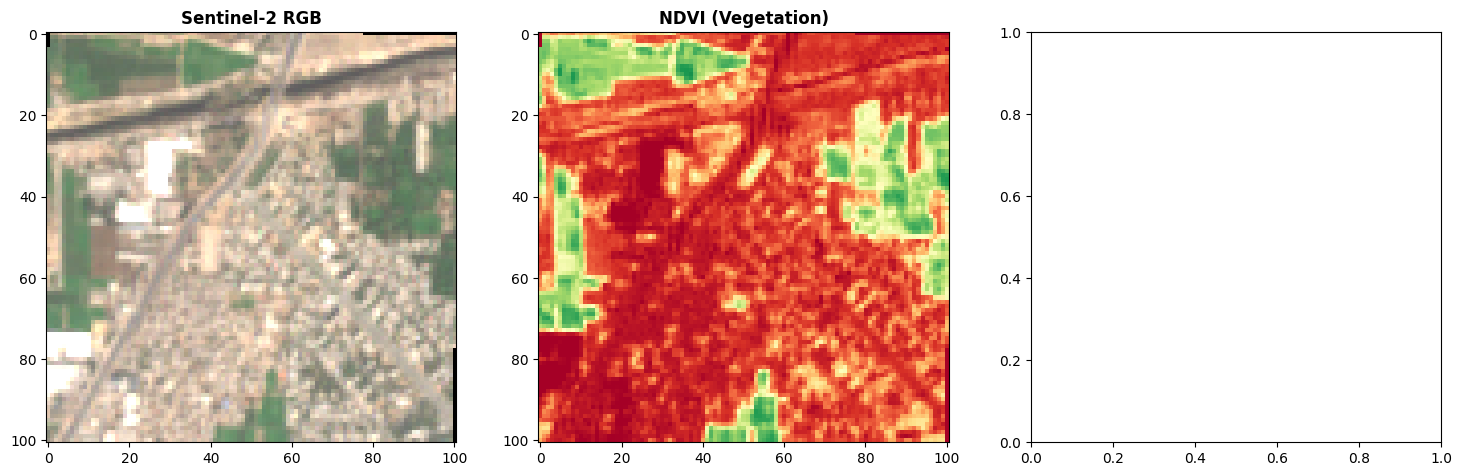

In [12]:
import ee
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Initialize
try:
    ee.Initialize(project='ee-mukskhan9999')
except:
    ee.Authenticate()
    ee.Initialize(project='ee-mukskhan9999')

# 1. Config
lat, lon = 31.39577858, 74.15519505
buffer = 500 
point = ee.Geometry.Point([lon, lat])
region = point.buffer(buffer).bounds()

# 2. Sentinel-2 with a "Fallback"
s2_col = (ee.ImageCollection("COPERNICUS/S2_SR")
          .filterBounds(region)
          .filterDate("2023-01-01", "2023-12-31") # Expanded date for safety
          .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 30))
          .sort("CLOUDY_PIXEL_PERCENTAGE"))

if s2_col.size().getInfo() == 0:
    raise ValueError("No Sentinel-2 images found! Try expanding the date range or cloud filter.")

# Get the cleanest single image instead of median (often sharper)
s2_img = s2_col.first().clip(region)

# 3. Sentinel-1 
s1_img = (ee.ImageCollection("COPERNICUS/S1_GRD")
          .filterBounds(region)
          .filter(ee.Filter.eq('instrumentMode', 'IW'))
          .filterDate("2023-01-01", "2023-12-31")
          .select("VV")
          .median()
          .clip(region))

# 4. Conversion Helper (More robust)
def get_pixels(image, bands, region):
    # Force a specific scale to ensure we get data
    pixel_data = image.sampleRectangle(region=region, defaultValue=0)
    arrays = [np.array(pixel_data.get(b).getInfo()) for b in bands]
    return np.stack(arrays, axis=-1)

# Fetch Data
rgb_np = get_pixels(s2_img, ["B4", "B3", "B2"], region)
ndvi_ee = s2_img.normalizedDifference(["B8", "B4"]).rename("nd")
ndvi_np = get_pixels(ndvi_ee, ["nd"], region).squeeze()
s1_np = get_pixels(s1_img, ["VV"], region).squeeze()

# 5. Normalization for Viz
# S2 values are 0-10000; scale for RGB
rgb_viz = np.clip(rgb_np / 3000.0, 0, 1) 

# SAR values are dB (usually -30 to 0). Let's stretch it.
s1_min, s1_max = np.percentile(s1_np, [2, 98])
s1_viz = np.clip((s1_np - s1_min) / (s1_max - s1_min), 0, 1)

# 6. Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(rgb_viz)
axes[0].set_title("Sentinel-2 RGB", fontweight='bold')

axes[1].imshow(ndvi_np, cmap='RdYlGn', vmin=0, vmax=0.8)
axes[1].set_title("NDVI (Vegetation)", fontweight='bold')

# Using your custom colors for SAR
colors = ['#0d0887','#46039f','#bd3786','#ed7953','#f0f921']
cmap_height = LinearSegmentedColormap.from_list('height', colors)
im3 = axes[2].imshow(s1_viz, cmap=cmap_height)
axes[2].set_title("SAR Intensity (Texture/Height)", fontweight='bold')

plt.tight_layout()
plt.show()

In [10]:
import ee
import folium

# -------------------------
# 1. Authenticate & Initialize
# -------------------------
ee.Authenticate()
ee.Initialize(project='ee-mukskhan9999')  # or ee.Initialize(project='your-project-id')

# -------------------------
# 2. Define Coordinate
# -------------------------
lat, lon = 31.39577858, 74.15519505  # Lahore (change if needed)
point = ee.Geometry.Point([lon, lat])

# -------------------------
# 3. Sentinel-2 (Optical)
# -------------------------
s2 = (
    ee.ImageCollection("COPERNICUS/S2_SR")
    .filterBounds(point)
    .filterDate("2023-01-01", "2023-01-31")
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
    .first()
)

print("S2 Image Info:")
print(s2.getInfo()["id"])

# -------------------------
# 4. Sentinel-1 (Radar)
# -------------------------
s1 = (
    ee.ImageCollection("COPERNICUS/S1_GRD")
    .filterBounds(point)
    .filterDate("2023-01-01", "2023-01-31")
    .filter(ee.Filter.eq("instrumentMode", "IW"))
    .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
    .first()
)

print("\nS1 Image Info:")
print(s1.getInfo()["id"])

# -------------------------
# 5. Visualization (Folium Map)
# -------------------------
def add_ee_layer(self, ee_image, vis_params, name):
    map_id_dict = ee.Image(ee_image).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr="Google Earth Engine",
        name=name,
        overlay=True,
        control=True
    ).add_to(self)

folium.Map.add_ee_layer = add_ee_layer

# Create map
Map = folium.Map(location=[lat, lon], zoom_start=10)

# S2 RGB
Map.add_ee_layer(
    s2,
    {"bands": ["B4", "B3", "B2"], "min": 0, "max": 3000},
    "Sentinel-2 RGB"
)

# S1 VV
Map.add_ee_layer(
    s1.select("VV"),
    {"min": -25, "max": 5},
    "Sentinel-1 VV"
)

folium.LayerControl().add_to(Map)

Map

S2 Image Info:
COPERNICUS/S2_SR/20230102T054231_20230102T054230_T43RDQ

S1 Image Info:
COPERNICUS/S1_GRD/S1A_IW_GRDH_1SDV_20230106T010006_20230106T010031_046656_059794_AD0C


In [3]:
import pandas as pd
from shapely import wkt
from shapely.errors import WKTReadingError

def check_georeference_errors(file_path):
    # Load the excel file
    # Ensure 'openpyxl' is installed: pip install openpyxl
    df = pd.read_excel(file_path)

    # Note: If sam_mask appears twice, pandas renames the second one to 'sam_mask.1'
    # We will look for the column that actually contains the WKT string
    polygon_col = 'polygon_wkt'
    mask_col = 'sam_mask_wkt' 

    error_count = 0
    total_rows = len(df)
    
    print(f"Processing {total_rows} rows...")

    for index, row in df.iterrows():
        try:
            # Parse the WKT strings into Shapely geometry objects
            poly_geom = wkt.loads(str(row[polygon_col]))
            mask_geom = wkt.loads(str(row[mask_col]))

            # Check if there is NO intersection between the two
            # .disjoint() returns True if the geometries do not share any space
            if poly_geom.disjoint(mask_geom):
                error_count += 1
                
        except (WKTReadingError, TypeError, ValueError):
            # Skip rows with empty or malformed geometry data
            continue

    print("-" * 30)
    print(f"Total Plots Checked: {total_rows}")
    print(f"Georeferencing Errors (No Intersection): {error_count}")
    print(f"Accuracy Rate: {((total_rows - error_count) / total_rows) * 100:.2f}%")
    print("-" * 30)

# To run this in your notebook:
# 1. Update the path to your actual file location
check_georeference_errors('final_dataset.xlsx')

D:\temp\ipykernel_2836\290845317.py:3: FutureWarning: WKTReadingError is deprecated and will be removed in a future version. Use ShapelyError instead (functions previously raising {name} will now raise a ShapelyError instead).
  from shapely.errors import WKTReadingError


Processing 19456 rows...
------------------------------
Total Plots Checked: 19456
Georeferencing Errors (No Intersection): 11010
Accuracy Rate: 43.41%
------------------------------
